## Imports and Settings

StatementMeta(, 83c8c680-78ca-4fde-9f0b-65df42b01a93, 5, Finished, Available, Finished, False)

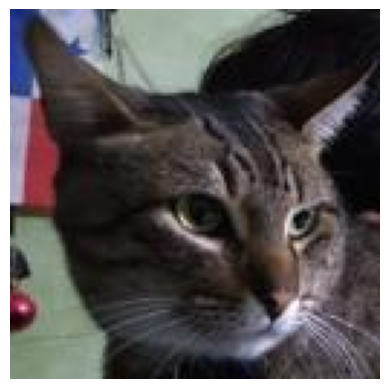

In [1]:
'''
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# Load image
image = mpimg.imread("/lakehouse/default/Files/gold/dataset_128/test/gato_jorge/IMG-20200429-WA0027.jpg")
# Let the axes disappear
plt.axis('off')
# Plot image in the output
image_plot = plt.imshow(image)
'''

StatementMeta(, 83c8c680-78ca-4fde-9f0b-65df42b01a93, 6, Finished, Available, Finished, False)

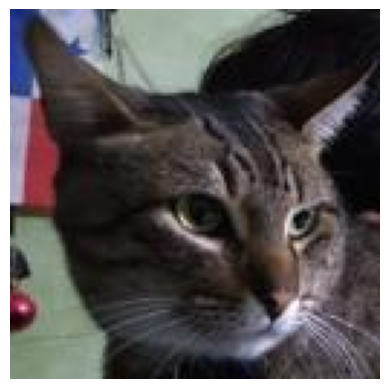

In [2]:
'''
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# Load image
image = mpimg.imread("/lakehouse/default/Files/gold/dataset_128/train/gato_jorge/IMG-20200429-WA0027.jpg")
# Let the axes disappear
plt.axis('off')
# Plot image in the output
image_plot = plt.imshow(image)
'''

In [6]:
from PIL import Image
import io
import os

StatementMeta(, 24038031-2e8b-4fbb-b124-3341c9a2dde2, 15, Finished, Available, Finished, False)

Test notebook execution

In [3]:
foreach_item ="128"

StatementMeta(, 24038031-2e8b-4fbb-b124-3341c9a2dde2, 12, Finished, Available, Finished, False)

In [4]:
# Cast the injected string to integer
target_size = int(image_size)  # e.g. 128, 224, 256...
print(f"Resizing images to: {target_size}x{target_size}")

StatementMeta(, 24038031-2e8b-4fbb-b124-3341c9a2dde2, 13, Finished, Available, Finished, False)

Resizing images to: 128x128


Processing cell

In [7]:
target_size = int(target_size)

# Root input path
input_root = "Files/images/raw"

# HEIC excluded for now
SUPPORTED_FORMATS = (".png", ".jpg", ".jpeg", ".heic", ".heif")
SKIPPED_FORMATS   = (".heic", ".heif")

# Dynamically list all subfolders
subfolders = [f.name for f in notebookutils.fs.ls(input_root) if f.isDir]
print(f"Found folders: {subfolders}")

for folder in subfolders:
    input_folder  = f"{input_root}/{folder}"
    output_folder = f"Files/silver/resized/{folder}/{target_size}"

    # Create output folder
    notebookutils.fs.mkdirs(output_folder)

    # List images
    try:
        files = notebookutils.fs.ls(input_folder)
    except:
        print(f"⚠️ Could not read: {input_folder}")
        continue

    for file in files:
        filename = file.name
        ext = os.path.splitext(filename)[1].lower()

        if ext in SKIPPED_FORMATS:
            print(f"⏭️ HEIC skipped (unsupported in pipeline): {filename}")
            continue

        if ext in SUPPORTED_FORMATS:

            # Copy to /tmp/ for processing
            notebookutils.fs.cp(
                f"{input_folder}/{filename}",
                f"file:/tmp/{filename}"
                )

                # Open and resize 
            with Image.open(f"/tmp/{filename}") as img:

                    # Convert to RGB
                img = img.convert("RGB")
                resized = img.resize((target_size, target_size))

                # Always save output as JPEG for consistency
                output_filename = os.path.splitext(filename)[0] + ".jpg"
                resized.save(f"/tmp/resized_{output_filename}", format="JPEG")

                notebookutils.fs.cp(
                    f"file:/tmp/resized_{output_filename}",
                    f"{output_folder}/{output_filename}"
                )
                print(f"✅ {folder}/{filename} → resized/{folder}/{target_size}/{output_filename}")

        else:
            print(f"⏭️ Skipping unsupported format: {filename}")

    print(f"🎉 Done! All folders resized to {target_size}x{target_size}")


StatementMeta(, 24038031-2e8b-4fbb-b124-3341c9a2dde2, 16, Finished, Available, Finished, False)

Found folders: ['gato_phil', 'perro_serena']
✅ gato_phil/20221009_141245.jpg → resized/gato_phil/128/20221009_141245.jpg
✅ gato_phil/20240213_145747.jpg → resized/gato_phil/128/20240213_145747.jpg
✅ gato_phil/20240213_145900.jpg → resized/gato_phil/128/20240213_145900.jpg
✅ gato_phil/20240412_220748.heic → resized/gato_phil/128/20240412_220748.jpg
✅ gato_phil/20240412_221432.heic → resized/gato_phil/128/20240412_221432.jpg
🎉 Done! All folders resized to 128x128
✅ perro_serena/IMG-20191224-WA0034.jpeg → resized/perro_serena/128/IMG-20191224-WA0034.jpg
✅ perro_serena/IMG-20200502-WA0015.jpg → resized/perro_serena/128/IMG-20200502-WA0015.jpg
✅ perro_serena/IMG-20201117-WA0018.jpg → resized/perro_serena/128/IMG-20201117-WA0018.jpg
✅ perro_serena/Screenshot_20250806_070536_WhatsApp.jpg → resized/perro_serena/128/Screenshot_20250806_070536_WhatsApp.jpg
🎉 Done! All folders resized to 128x128


StatementMeta(, 8c07481a-f62c-4fa0-9944-de6ceb3d7598, 5, Finished, Available, Finished, False)

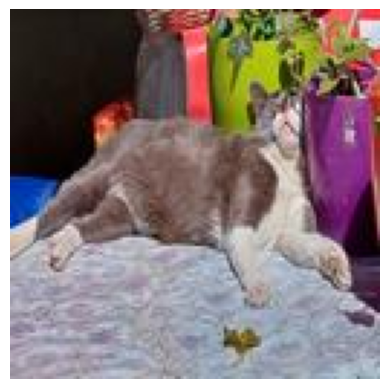

In [1]:
'''
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# Load image
image = mpimg.imread("/lakehouse/default/Files/gold/dataset_all/test/gato_phil/20221009_141245.jpg")
# Let the axes disappear
plt.axis('off')
# Plot image in the output
image_plot = plt.imshow(image)
'''